# DhakaNest Rent Prediction — XGBoost

This notebook trains, tunes, validates, analyzes, and exports the XGBoost
rent-prediction candidate using the frozen DhakaNest training and validation
datasets.

The official test dataset remains untouched until the final algorithm has
been selected.

In [1]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
%pip install -q --upgrade xgboost

In [3]:
from pathlib import Path
from datetime import datetime, timezone
from time import perf_counter

import hashlib
import json
import os
import platform
import random
import shutil
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
import xgboost as xgb

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
    median_absolute_error,
    r2_score,
)
from sklearn.model_selection import GroupKFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

warnings.filterwarnings("ignore")

print("Python:", platform.python_version())
print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("Scikit-learn:", sklearn.__version__)
print("XGBoost:", xgb.__version__)
print("Joblib:", joblib.__version__)

Python: 3.12.13
Pandas: 2.2.2
NumPy: 2.0.2
Scikit-learn: 1.6.1
XGBoost: 3.3.0
Joblib: 1.5.3


In [4]:
RANDOM_STATE = 42

os.environ["PYTHONHASHSEED"] = str(RANDOM_STATE)

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

print("Random state:", RANDOM_STATE)

Random state: 42


In [5]:
PROJECT_ROOT = Path("/content/drive/MyDrive/DhakaNest_ML")

DATA_DIR = PROJECT_ROOT / "data"
SPLITS_DIR = DATA_DIR / "splits"

REPORTS_DIR = PROJECT_ROOT / "reports"
METRICS_DIR = REPORTS_DIR / "metrics"
SEGMENT_DIR = REPORTS_DIR / "segment_evaluation"
XGB_FIGURES_DIR = REPORTS_DIR / "figures" / "xgboost"

ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"
XGB_ARTIFACT_DIR = ARTIFACTS_DIR / "candidates" / "xgboost"

MANIFESTS_DIR = PROJECT_ROOT / "manifests"
LOGS_DIR = PROJECT_ROOT / "logs"

TRAIN_PATH = SPLITS_DIR / "train.csv"
VALIDATION_PATH = SPLITS_DIR / "validation.csv"
TEST_PATH = SPLITS_DIR / "test.csv"

UNSEEN_TRAIN_PATH = (
    SPLITS_DIR / "unseen_micro_area_train.csv"
)

UNSEEN_CHALLENGE_PATH = (
    SPLITS_DIR / "unseen_micro_area_challenge.csv"
)

for directory in [
    METRICS_DIR,
    SEGMENT_DIR,
    XGB_FIGURES_DIR,
    XGB_ARTIFACT_DIR,
    MANIFESTS_DIR,
    LOGS_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("XGBoost artifact directory:", XGB_ARTIFACT_DIR)

Project root: /content/drive/MyDrive/DhakaNest_ML
XGBoost artifact directory: /content/drive/MyDrive/DhakaNest_ML/artifacts/candidates/xgboost


In [6]:
required_files = [
    TRAIN_PATH,
    VALIDATION_PATH,
    TEST_PATH,
    UNSEEN_TRAIN_PATH,
    UNSEEN_CHALLENGE_PATH,
]

missing_files = [
    str(path)
    for path in required_files
    if not path.exists()
]

if missing_files:
    raise FileNotFoundError(
        "Missing required files:\n"
        + "\n".join(missing_files)
    )

print("All required files exist.")
print("The official test file exists but will not be loaded.")

All required files exist.
The official test file exists but will not be loaded.


In [7]:
LOCAL_WORK_DIR = Path("/content/dhakanest_xgboost")
LOCAL_DATA_DIR = LOCAL_WORK_DIR / "data"

LOCAL_DATA_DIR.mkdir(parents=True, exist_ok=True)

local_train_path = LOCAL_DATA_DIR / "train.csv"
local_validation_path = LOCAL_DATA_DIR / "validation.csv"

local_unseen_train_path = (
    LOCAL_DATA_DIR / "unseen_micro_area_train.csv"
)

local_unseen_challenge_path = (
    LOCAL_DATA_DIR / "unseen_micro_area_challenge.csv"
)

shutil.copy2(TRAIN_PATH, local_train_path)
shutil.copy2(VALIDATION_PATH, local_validation_path)

shutil.copy2(
    UNSEEN_TRAIN_PATH,
    local_unseen_train_path,
)

shutil.copy2(
    UNSEEN_CHALLENGE_PATH,
    local_unseen_challenge_path,
)

print("Working files copied to:", LOCAL_DATA_DIR)

Working files copied to: /content/dhakanest_xgboost/data


In [8]:
train_df = pd.read_csv(local_train_path)
validation_df = pd.read_csv(local_validation_path)

unseen_train_df = pd.read_csv(
    local_unseen_train_path
)

unseen_challenge_df = pd.read_csv(
    local_unseen_challenge_path
)

print("Training shape:", train_df.shape)
print("Validation shape:", validation_df.shape)
print("Unseen training shape:", unseen_train_df.shape)
print("Unseen challenge shape:", unseen_challenge_df.shape)

Training shape: (10668, 11)
Validation shape: (2289, 11)
Unseen training shape: (9549, 11)
Unseen challenge shape: (1119, 11)


In [9]:
CATEGORICAL_FEATURES = [
    "broad_area",
    "model_micro_area",
]

NUMERICAL_FEATURES = [
    "area_sqft",
    "bedrooms",
    "bathrooms",
]

FEATURE_COLUMNS = (
    CATEGORICAL_FEATURES
    + NUMERICAL_FEATURES
)

TARGET_COLUMN = "base_rent_bdt"
GROUP_COLUMN = "duplicate_group_id"

print("Categorical features:", CATEGORICAL_FEATURES)
print("Numerical features:", NUMERICAL_FEATURES)
print("Target:", TARGET_COLUMN)

Categorical features: ['broad_area', 'model_micro_area']
Numerical features: ['area_sqft', 'bedrooms', 'bathrooms']
Target: base_rent_bdt


In [10]:
REQUIRED_COLUMNS = [
    *FEATURE_COLUMNS,
    TARGET_COLUMN,
    GROUP_COLUMN,
    "record_id",
    "location_raw",
    "micro_area",
    "micro_area_support_count",
]

for dataset_name, dataframe in [
    ("train", train_df),
    ("validation", validation_df),
    ("unseen_train", unseen_train_df),
    ("unseen_challenge", unseen_challenge_df),
]:
    missing_columns = [
        column
        for column in REQUIRED_COLUMNS
        if column not in dataframe.columns
    ]

    if missing_columns:
        raise ValueError(
            f"{dataset_name} is missing columns: "
            f"{missing_columns}"
        )

    model_columns = FEATURE_COLUMNS + [TARGET_COLUMN]

    if dataframe[model_columns].isna().any().any():
        raise ValueError(
            f"{dataset_name} contains missing model values."
        )

    if (dataframe["area_sqft"] <= 0).any():
        raise ValueError(
            f"{dataset_name} contains invalid area values."
        )

    if (dataframe["bedrooms"] <= 0).any():
        raise ValueError(
            f"{dataset_name} contains invalid bedroom values."
        )

    if (dataframe["bathrooms"] <= 0).any():
        raise ValueError(
            f"{dataset_name} contains invalid bathroom values."
        )

    if (dataframe[TARGET_COLUMN] <= 0).any():
        raise ValueError(
            f"{dataset_name} contains invalid rent values."
        )

print("Dataset schema and value validation passed.")

Dataset schema and value validation passed.


In [11]:
train_record_ids = set(train_df["record_id"])
validation_record_ids = set(validation_df["record_id"])

train_groups = set(train_df[GROUP_COLUMN])
validation_groups = set(validation_df[GROUP_COLUMN])

assert train_record_ids.isdisjoint(
    validation_record_ids
), "Record leakage detected."

assert train_groups.isdisjoint(
    validation_groups
), "Duplicate-group leakage detected."

print("Training and validation isolation passed.")

Training and validation isolation passed.


In [12]:
X_train = train_df[FEATURE_COLUMNS].copy()
y_train = train_df[TARGET_COLUMN].copy()

X_validation = validation_df[
    FEATURE_COLUMNS
].copy()

y_validation = validation_df[
    TARGET_COLUMN
].copy()

training_groups = train_df[GROUP_COLUMN].copy()

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_validation:", X_validation.shape)
print("y_validation:", y_validation.shape)
print("Training groups:", training_groups.nunique())

X_train: (10668, 5)
y_train: (10668,)
X_validation: (2289, 5)
y_validation: (2289,)
Training groups: 9723


In [13]:
environment_info = {
    "python_version": platform.python_version(),
    "pandas_version": pd.__version__,
    "numpy_version": np.__version__,
    "scikit_learn_version": sklearn.__version__,
    "xgboost_version": xgb.__version__,
    "joblib_version": joblib.__version__,
    "random_state": RANDOM_STATE,
    "created_at_utc": datetime.now(
        timezone.utc
    ).isoformat(),
}

ENVIRONMENT_PATH = (
    XGB_ARTIFACT_DIR / "training_environment.json"
)

with ENVIRONMENT_PATH.open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        environment_info,
        file,
        indent=2,
    )

print(json.dumps(environment_info, indent=2))
print("Saved:", ENVIRONMENT_PATH)

{
  "python_version": "3.12.13",
  "pandas_version": "2.2.2",
  "numpy_version": "2.0.2",
  "scikit_learn_version": "1.6.1",
  "xgboost_version": "3.3.0",
  "joblib_version": "1.5.3",
  "random_state": 42,
  "created_at_utc": "2026-07-31T05:09:30.545618+00:00"
}
Saved: /content/drive/MyDrive/DhakaNest_ML/artifacts/candidates/xgboost/training_environment.json


## Preprocessing

The broad area and model micro-area are one-hot encoded. Numerical features
receive median imputation if required. Categories that were not seen during
training can be processed without raising an error.

In [14]:
def create_preprocessor(
    categorical_features=None,
    numerical_features=None,
):
    if categorical_features is None:
        categorical_features = CATEGORICAL_FEATURES

    if numerical_features is None:
        numerical_features = NUMERICAL_FEATURES

    transformers = []

    if categorical_features:
        categorical_pipeline = Pipeline(
            steps=[
                (
                    "imputer",
                    SimpleImputer(
                        strategy="most_frequent"
                    ),
                ),
                (
                    "onehot",
                    OneHotEncoder(
                        handle_unknown="ignore",
                        sparse_output=True,
                    ),
                ),
            ]
        )

        transformers.append(
            (
                "categorical",
                categorical_pipeline,
                categorical_features,
            )
        )

    if numerical_features:
        numerical_pipeline = Pipeline(
            steps=[
                (
                    "imputer",
                    SimpleImputer(
                        strategy="median"
                    ),
                ),
            ]
        )

        transformers.append(
            (
                "numerical",
                numerical_pipeline,
                numerical_features,
            )
        )

    return ColumnTransformer(
        transformers=transformers,
        remainder="drop",
        sparse_threshold=1.0,
    )


preprocessor_preview = create_preprocessor()

print(preprocessor_preview)

ColumnTransformer(sparse_threshold=1.0,
                  transformers=[('categorical',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['broad_area', 'model_micro_area']),
                                ('numerical',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median'))]),
                                 ['area_sqft', 'bedrooms', 'bathrooms'])])


In [15]:
def calculate_regression_metrics(
    y_true,
    y_pred,
):
    y_true_array = np.asarray(
        y_true,
        dtype=float,
    )

    y_pred_array = np.asarray(
        y_pred,
        dtype=float,
    )

    absolute_errors = np.abs(
        y_true_array - y_pred_array
    )

    return {
        "mae_bdt": float(
            mean_absolute_error(
                y_true_array,
                y_pred_array,
            )
        ),
        "rmse_bdt": float(
            np.sqrt(
                mean_squared_error(
                    y_true_array,
                    y_pred_array,
                )
            )
        ),
        "r2": float(
            r2_score(
                y_true_array,
                y_pred_array,
            )
        ),
        "mape_percent": float(
            mean_absolute_percentage_error(
                y_true_array,
                y_pred_array,
            )
            * 100
        ),
        "median_absolute_error_bdt": float(
            median_absolute_error(
                y_true_array,
                y_pred_array,
            )
        ),
        "p90_absolute_error_bdt": float(
            np.percentile(
                absolute_errors,
                90,
            )
        ),
    }

In [16]:
def convert_predictions_to_bdt(
    predictions,
    target_strategy,
):
    predictions = np.asarray(
        predictions,
        dtype=float,
    )

    if target_strategy == "log1p":
        predictions = np.expm1(predictions)

    return np.maximum(predictions, 0)


def evaluate_encoded_xgb_model(
    model,
    X_encoded,
    y_true,
    target_strategy,
):
    prediction_start = perf_counter()

    raw_predictions = model.predict(
        X_encoded
    )

    prediction_seconds = (
        perf_counter() - prediction_start
    )

    predictions_bdt = convert_predictions_to_bdt(
        raw_predictions,
        target_strategy,
    )

    metrics = calculate_regression_metrics(
        y_true,
        predictions_bdt,
    )

    metrics["prediction_time_seconds"] = float(
        prediction_seconds
    )

    metrics["milliseconds_per_record"] = float(
        prediction_seconds
        / max(len(y_true), 1)
        * 1000
    )

    return metrics, predictions_bdt

In [34]:
def flatten_model_result(
    model_name,
    train_metrics,
    validation_metrics,
    training_time_seconds,
):
    return {
        "model_name": model_name,
        "training_time_seconds": float(
            training_time_seconds
        ),
        "train_mae_bdt": float(
            train_metrics["mae_bdt"]
        ),
        "validation_mae_bdt": float(
            validation_metrics["mae_bdt"]
        ),
        "validation_rmse_bdt": float(
            validation_metrics["rmse_bdt"]
        ),
        "validation_r2": float(
            validation_metrics["r2"]
        ),
        "validation_mape_percent": float(
            validation_metrics["mape_percent"]
        ),
        "validation_median_absolute_error_bdt": float(
            validation_metrics[
                "median_absolute_error_bdt"
            ]
        ),
        "validation_p90_absolute_error_bdt": float(
            validation_metrics[
                "p90_absolute_error_bdt"
            ]
        ),
        "train_validation_mae_gap_bdt": float(
            validation_metrics["mae_bdt"]
            - train_metrics["mae_bdt"]
        ),
        "validation_prediction_time_seconds": float(
            validation_metrics.get(
                "prediction_time_seconds",
                0.0,
            )
        ),
    }

print("Updated comparison helper loaded successfully.")

Updated comparison helper loaded successfully.


## Dummy Median Baseline

The baseline predicts the median training rent for every validation property.
The XGBoost candidate must clearly outperform this result.

In [18]:
dummy_model = DummyRegressor(
    strategy="median"
)

dummy_X_train = np.zeros(
    shape=(len(y_train), 1)
)

dummy_X_validation = np.zeros(
    shape=(len(y_validation), 1)
)

dummy_start = perf_counter()

dummy_model.fit(
    dummy_X_train,
    y_train,
)

dummy_training_time = (
    perf_counter() - dummy_start
)

dummy_train_predictions = dummy_model.predict(
    dummy_X_train
)

dummy_validation_predictions = dummy_model.predict(
    dummy_X_validation
)

dummy_train_metrics = calculate_regression_metrics(
    y_train,
    dummy_train_predictions,
)

dummy_validation_metrics = (
    calculate_regression_metrics(
        y_validation,
        dummy_validation_predictions,
    )
)

print("Dummy training metrics:")
display(pd.DataFrame([dummy_train_metrics]))

print("Dummy validation metrics:")
display(pd.DataFrame([dummy_validation_metrics]))

Dummy training metrics:


,mae_bdt,rmse_bdt,r2,mape_percent,median_absolute_error_bdt,p90_absolute_error_bdt
0,9785.46213,25280.329656,-0.062665,32.313069,5000.0,18000.0


Dummy validation metrics:


,mae_bdt,rmse_bdt,r2,mape_percent,median_absolute_error_bdt,p90_absolute_error_bdt
0,9648.186981,23000.801441,-0.072099,32.733671,5000.0,18200.0


## Initial XGBoost Model

An initial model is trained before tuning to establish an XGBoost reference
result.

In [19]:
initial_xgb_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            create_preprocessor(),
        ),
        (
            "model",
            xgb.XGBRegressor(
                objective="reg:squarederror",
                n_estimators=600,
                learning_rate=0.05,
                max_depth=6,
                min_child_weight=1,
                subsample=0.85,
                colsample_bytree=0.85,
                reg_alpha=0.0,
                reg_lambda=1.0,
                gamma=0.0,
                tree_method="hist",
                eval_metric="mae",
                random_state=RANDOM_STATE,
                n_jobs=-1,
                verbosity=0,
            ),
        ),
    ]
)

In [20]:
initial_start = perf_counter()

initial_xgb_pipeline.fit(
    X_train,
    y_train,
)

initial_training_time = (
    perf_counter() - initial_start
)

initial_train_prediction_start = perf_counter()

initial_train_predictions = (
    initial_xgb_pipeline.predict(
        X_train
    )
)

initial_train_prediction_time = (
    perf_counter()
    - initial_train_prediction_start
)

initial_validation_prediction_start = (
    perf_counter()
)

initial_validation_predictions = (
    initial_xgb_pipeline.predict(
        X_validation
    )
)

initial_validation_prediction_time = (
    perf_counter()
    - initial_validation_prediction_start
)

initial_train_metrics = (
    calculate_regression_metrics(
        y_train,
        initial_train_predictions,
    )
)

initial_validation_metrics = (
    calculate_regression_metrics(
        y_validation,
        initial_validation_predictions,
    )
)

initial_train_metrics[
    "prediction_time_seconds"
] = initial_train_prediction_time

initial_validation_metrics[
    "prediction_time_seconds"
] = initial_validation_prediction_time

print("Initial XGBoost training metrics:")
display(pd.DataFrame([initial_train_metrics]))

print("Initial XGBoost validation metrics:")
display(pd.DataFrame([initial_validation_metrics]))

Initial XGBoost training metrics:


,mae_bdt,rmse_bdt,r2,mape_percent,median_absolute_error_bdt,p90_absolute_error_bdt,prediction_time_seconds
0,2914.708589,7664.424792,0.902323,12.023288,1684.980469,5649.967383,0.106513


Initial XGBoost validation metrics:


,mae_bdt,rmse_bdt,r2,mape_percent,median_absolute_error_bdt,p90_absolute_error_bdt,prediction_time_seconds
0,3648.653303,8700.4791,0.846596,13.444639,1785.576172,6639.425,0.028925


## XGBoost Hyperparameter Tuning

Randomized hyperparameter search uses five-fold GroupKFold cross-validation.
Only the training dataset is used during this search.

In [21]:
tuning_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            create_preprocessor(),
        ),
        (
            "model",
            xgb.XGBRegressor(
                objective="reg:squarederror",
                tree_method="hist",
                eval_metric="mae",
                random_state=RANDOM_STATE,
                n_jobs=1,
                verbosity=0,
            ),
        ),
    ]
)

In [22]:
parameter_distributions = {
    "model__n_estimators": [
        300,
        500,
        800,
        1100,
    ],
    "model__learning_rate": [
        0.02,
        0.04,
        0.06,
        0.10,
    ],
    "model__max_depth": [
        3,
        5,
        7,
        9,
    ],
    "model__min_child_weight": [
        1,
        3,
        5,
        10,
    ],
    "model__subsample": [
        0.70,
        0.85,
        1.0,
    ],
    "model__colsample_bytree": [
        0.70,
        0.85,
        1.0,
    ],
    "model__reg_alpha": [
        0.0,
        0.01,
        0.10,
        1.0,
    ],
    "model__reg_lambda": [
        1.0,
        5.0,
        10.0,
    ],
    "model__gamma": [
        0.0,
        0.05,
        0.10,
        0.30,
    ],
}

print("XGBoost search space configured.")

XGBoost search space configured.


In [23]:
group_cv = GroupKFold(
    n_splits=5
)

search = RandomizedSearchCV(
    estimator=tuning_pipeline,
    param_distributions=parameter_distributions,
    n_iter=18,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    cv=group_cv,
    verbose=2,
    random_state=RANDOM_STATE,
    refit=True,
    return_train_score=True,
    error_score="raise",
    pre_dispatch="2*n_jobs",
)

print("Search candidates:", search.n_iter)
print("Cross-validation folds:", 5)
print("Total model fits:", search.n_iter * 5)

Search candidates: 18
Cross-validation folds: 5
Total model fits: 90


In [24]:
tuning_start = perf_counter()

search.fit(
    X_train,
    y_train,
    groups=training_groups,
)

tuning_time_seconds = (
    perf_counter() - tuning_start
)

print("XGBoost tuning completed.")
print(
    "Tuning time in seconds:",
    round(tuning_time_seconds, 2),
)

print(
    "Best cross-validation MAE:",
    round(-search.best_score_, 2),
)

print("Best parameters:")

display(
    pd.DataFrame(
        list(search.best_params_.items()),
        columns=["parameter", "value"],
    )
)

Fitting 5 folds for each of 18 candidates, totalling 90 fits
XGBoost tuning completed.
Tuning time in seconds: 59.7
Best cross-validation MAE: 3621.79
Best parameters:


,parameter,value
0,model__subsample,0.85
1,model__reg_lambda,1.00
2,model__reg_alpha,0.00
3,model__n_estimators,800.00
4,model__min_child_weight,10.00
5,model__max_depth,7.00
6,model__learning_rate,0.06
7,model__gamma,0.00
8,model__colsample_bytree,0.70


In [25]:
cv_results_df = pd.DataFrame(
    search.cv_results_
)

cv_results_df["mean_test_mae_bdt"] = (
    -cv_results_df["mean_test_score"]
)

cv_results_df["mean_train_mae_bdt"] = (
    -cv_results_df["mean_train_score"]
)

cv_results_df = cv_results_df.sort_values(
    "mean_test_mae_bdt",
    ascending=True,
)

CV_RESULTS_PATH = (
    METRICS_DIR
    / "xgboost_cv_results.csv"
)

cv_results_df.to_csv(
    CV_RESULTS_PATH,
    index=False,
)

display(
    cv_results_df[
        [
            "rank_test_score",
            "mean_test_mae_bdt",
            "std_test_score",
            "mean_train_mae_bdt",
            "mean_fit_time",
            "params",
        ]
    ].head(18)
)

print("Saved:", CV_RESULTS_PATH)

,rank_test_score,mean_test_mae_bdt,std_test_score,mean_train_mae_bdt,mean_fit_time,params
6,1,3621.794141,130.287064,3107.156152,1.212039,"{'model__subsample': 0.85, 'model__reg_lambda'..."
17,2,3641.368066,163.547786,2783.025830,1.974960,"{'model__subsample': 1.0, 'model__reg_lambda':..."
12,3,3658.649170,119.870873,3206.041406,0.770640,"{'model__subsample': 0.7, 'model__reg_lambda':..."
13,4,3668.033594,172.701134,3027.718848,1.063386,"{'model__subsample': 1.0, 'model__reg_lambda':..."
5,5,3672.842725,173.162880,2871.404492,0.838451,"{'model__subsample': 0.85, 'model__reg_lambda'..."
0,6,3685.496729,169.581571,2736.593164,1.508026,"{'model__subsample': 0.7, 'model__reg_lambda':..."
9,7,3697.930566,125.811283,3140.283691,1.719366,"{'model__subsample': 0.7, 'model__reg_lambda':..."
1,8,3719.174512,168.276815,3371.973389,0.960837,"{'model__subsample': 1.0, 'model__reg_lambda':..."
7,9,3728.284766,171.861647,2566.236475,0.988575,"{'model__subsample': 0.7, 'model__reg_lambda':..."
10,10,3732.109033,149.560057,3456.421729,0.513536,"{'model__subsample': 0.85, 'model__reg_lambda'..."


Saved: /content/drive/MyDrive/DhakaNest_ML/reports/metrics/xgboost_cv_results.csv


In [26]:
best_search_parameters = {
    key.replace("model__", ""): value
    for key, value in search.best_params_.items()
}

searched_n_estimators = (
    best_search_parameters.pop(
        "n_estimators"
    )
)

print(
    "Best search n_estimators:",
    searched_n_estimators,
)

print("Best core parameters:")

display(
    pd.DataFrame(
        list(best_search_parameters.items()),
        columns=["parameter", "value"],
    )
)

Best search n_estimators: 800
Best core parameters:


,parameter,value
0,subsample,0.85
1,reg_lambda,1.00
2,reg_alpha,0.00
3,min_child_weight,10.00
4,max_depth,7.00
5,learning_rate,0.06
6,gamma,0.00
7,colsample_bytree,0.70


In [27]:
final_preprocessor = create_preprocessor()

X_train_encoded = (
    final_preprocessor.fit_transform(
        X_train
    )
)

X_validation_encoded = (
    final_preprocessor.transform(
        X_validation
    )
)

print(
    "Encoded training shape:",
    X_train_encoded.shape,
)

print(
    "Encoded validation shape:",
    X_validation_encoded.shape,
)

Encoded training shape: (10668, 268)
Encoded validation shape: (2289, 268)


In [28]:
MAX_FINAL_ESTIMATORS = 3000
EARLY_STOPPING_ROUNDS = 75


def create_final_xgb_model():
    return xgb.XGBRegressor(
        objective="reg:squarederror",
        n_estimators=MAX_FINAL_ESTIMATORS,
        tree_method="hist",
        eval_metric="mae",
        early_stopping_rounds=(
            EARLY_STOPPING_ROUNDS
        ),
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=0,
        **best_search_parameters,
    )


print(
    "Maximum estimators:",
    MAX_FINAL_ESTIMATORS,
)

print(
    "Early stopping rounds:",
    EARLY_STOPPING_ROUNDS,
)

Maximum estimators: 3000
Early stopping rounds: 75


## Final Raw-Target XGBoost

The tuned XGBoost configuration is trained on the original BDT rent target
with validation-based early stopping.

In [29]:
raw_xgb_model = create_final_xgb_model()

raw_training_start = perf_counter()

raw_xgb_model.fit(
    X_train_encoded,
    y_train,
    eval_set=[
        (
            X_train_encoded,
            y_train,
        ),
        (
            X_validation_encoded,
            y_validation,
        ),
    ],
    verbose=False,
)

raw_training_time = (
    perf_counter() - raw_training_start
)

raw_train_metrics, raw_train_predictions = (
    evaluate_encoded_xgb_model(
        raw_xgb_model,
        X_train_encoded,
        y_train,
        target_strategy="raw",
    )
)

raw_validation_metrics, raw_validation_predictions = (
    evaluate_encoded_xgb_model(
        raw_xgb_model,
        X_validation_encoded,
        y_validation,
        target_strategy="raw",
    )
)

print("Raw-target best iteration:")
print(raw_xgb_model.best_iteration)

print("Raw-target best validation score:")
print(raw_xgb_model.best_score)

print("\nRaw-target training metrics:")
display(pd.DataFrame([raw_train_metrics]))

print("\nRaw-target validation metrics:")
display(pd.DataFrame([raw_validation_metrics]))

Raw-target best iteration:
433
Raw-target best validation score:
3683.357224770642

Raw-target training metrics:


,mae_bdt,rmse_bdt,r2,mape_percent,median_absolute_error_bdt,p90_absolute_error_bdt,prediction_time_seconds,milliseconds_per_record
0,3237.689324,8559.285282,0.878184,12.651523,1733.259766,6233.301758,0.07583,0.007108



Raw-target validation metrics:


,mae_bdt,rmse_bdt,r2,mape_percent,median_absolute_error_bdt,p90_absolute_error_bdt,prediction_time_seconds,milliseconds_per_record
0,3683.357225,8615.813933,0.849568,13.567591,1807.495117,6792.076953,0.016739,0.007313


## Final Log-Target XGBoost

The same tuned configuration is trained using `log1p(base_rent_bdt)`.
Predictions are converted back to BDT before calculating evaluation metrics.

In [30]:
y_train_log = np.log1p(
    y_train.to_numpy()
)

y_validation_log = np.log1p(
    y_validation.to_numpy()
)

log_xgb_model = create_final_xgb_model()

log_training_start = perf_counter()

log_xgb_model.fit(
    X_train_encoded,
    y_train_log,
    eval_set=[
        (
            X_train_encoded,
            y_train_log,
        ),
        (
            X_validation_encoded,
            y_validation_log,
        ),
    ],
    verbose=False,
)

log_training_time = (
    perf_counter() - log_training_start
)

log_train_metrics, log_train_predictions = (
    evaluate_encoded_xgb_model(
        log_xgb_model,
        X_train_encoded,
        y_train,
        target_strategy="log1p",
    )
)

log_validation_metrics, log_validation_predictions = (
    evaluate_encoded_xgb_model(
        log_xgb_model,
        X_validation_encoded,
        y_validation,
        target_strategy="log1p",
    )
)

print("Log-target best iteration:")
print(log_xgb_model.best_iteration)

print("Log-target best validation score in log space:")
print(log_xgb_model.best_score)

print("\nLog-target training metrics in BDT:")
display(pd.DataFrame([log_train_metrics]))

print("\nLog-target validation metrics in BDT:")
display(pd.DataFrame([log_validation_metrics]))

Log-target best iteration:
467
Log-target best validation score in log space:
0.12618076712765408

Log-target training metrics in BDT:


,mae_bdt,rmse_bdt,r2,mape_percent,median_absolute_error_bdt,p90_absolute_error_bdt,prediction_time_seconds,milliseconds_per_record
0,3100.15849,9188.091866,0.859628,11.414735,1544.356821,5855.088655,0.081449,0.007635



Log-target validation metrics in BDT:


,mae_bdt,rmse_bdt,r2,mape_percent,median_absolute_error_bdt,p90_absolute_error_bdt,prediction_time_seconds,milliseconds_per_record
0,3571.573025,8842.536408,0.841546,12.68124,1689.224844,6454.955466,0.018288,0.00799


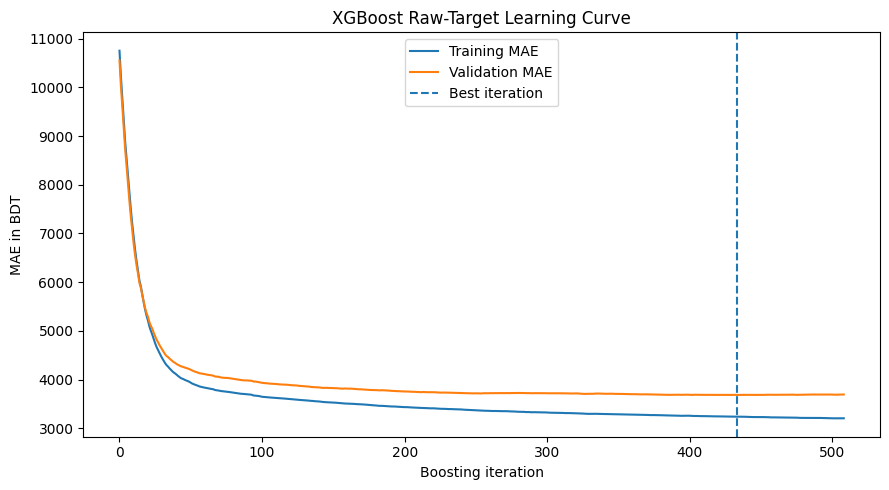

Saved: /content/drive/MyDrive/DhakaNest_ML/reports/figures/xgboost/raw_target_learning_curve.png


In [31]:
raw_evaluation_results = (
    raw_xgb_model.evals_result()
)

raw_train_mae_history = (
    raw_evaluation_results[
        "validation_0"
    ]["mae"]
)

raw_validation_mae_history = (
    raw_evaluation_results[
        "validation_1"
    ]["mae"]
)

plt.figure(figsize=(9, 5))

plt.plot(
    raw_train_mae_history,
    label="Training MAE",
)

plt.plot(
    raw_validation_mae_history,
    label="Validation MAE",
)

plt.axvline(
    raw_xgb_model.best_iteration,
    linestyle="--",
    label="Best iteration",
)

plt.xlabel("Boosting iteration")
plt.ylabel("MAE in BDT")
plt.title("XGBoost Raw-Target Learning Curve")
plt.legend()
plt.tight_layout()

RAW_LEARNING_CURVE_PATH = (
    XGB_FIGURES_DIR
    / "raw_target_learning_curve.png"
)

plt.savefig(
    RAW_LEARNING_CURVE_PATH,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print("Saved:", RAW_LEARNING_CURVE_PATH)

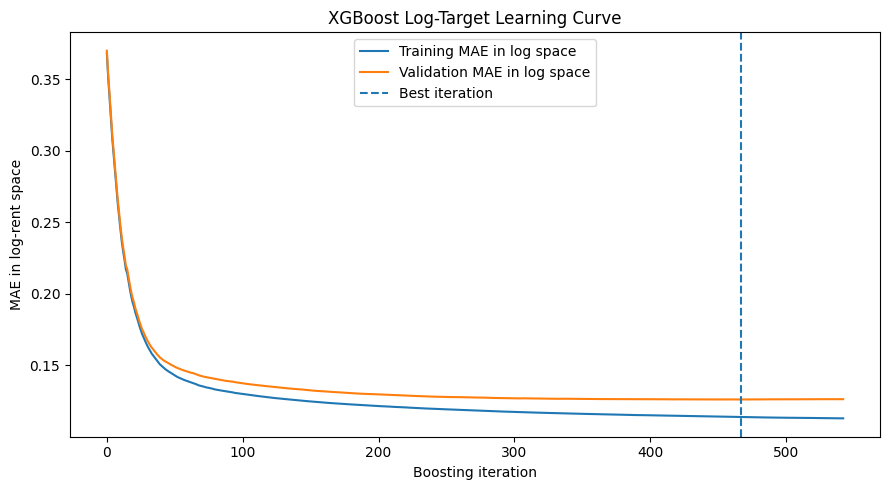

Saved: /content/drive/MyDrive/DhakaNest_ML/reports/figures/xgboost/log_target_learning_curve.png


In [32]:
log_evaluation_results = (
    log_xgb_model.evals_result()
)

log_train_mae_history = (
    log_evaluation_results[
        "validation_0"
    ]["mae"]
)

log_validation_mae_history = (
    log_evaluation_results[
        "validation_1"
    ]["mae"]
)

plt.figure(figsize=(9, 5))

plt.plot(
    log_train_mae_history,
    label="Training MAE in log space",
)

plt.plot(
    log_validation_mae_history,
    label="Validation MAE in log space",
)

plt.axvline(
    log_xgb_model.best_iteration,
    linestyle="--",
    label="Best iteration",
)

plt.xlabel("Boosting iteration")
plt.ylabel("MAE in log-rent space")
plt.title("XGBoost Log-Target Learning Curve")
plt.legend()
plt.tight_layout()

LOG_LEARNING_CURVE_PATH = (
    XGB_FIGURES_DIR
    / "log_target_learning_curve.png"
)

plt.savefig(
    LOG_LEARNING_CURVE_PATH,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print("Saved:", LOG_LEARNING_CURVE_PATH)

In [35]:
comparison_rows = [
    flatten_model_result(
        "Dummy Median Baseline",
        dummy_train_metrics,
        dummy_validation_metrics,
        dummy_training_time,
    ),
    flatten_model_result(
        "Initial XGBoost",
        initial_train_metrics,
        initial_validation_metrics,
        initial_training_time,
    ),
    flatten_model_result(
        "Tuned XGBoost — Raw Target",
        raw_train_metrics,
        raw_validation_metrics,
        raw_training_time,
    ),
    flatten_model_result(
        "Tuned XGBoost — Log Target",
        log_train_metrics,
        log_validation_metrics,
        log_training_time,
    ),
]

xgb_comparison_df = pd.DataFrame(
    comparison_rows
).sort_values(
    "validation_mae_bdt",
    ascending=True,
)

XGB_COMPARISON_PATH = (
    METRICS_DIR
    / "xgboost_validation_comparison.csv"
)

xgb_comparison_df.to_csv(
    XGB_COMPARISON_PATH,
    index=False,
)

display(xgb_comparison_df)

print("Saved:", XGB_COMPARISON_PATH)

,model_name,training_time_seconds,train_mae_bdt,validation_mae_bdt,validation_rmse_bdt,validation_r2,validation_mape_percent,validation_median_absolute_error_bdt,validation_p90_absolute_error_bdt,train_validation_mae_gap_bdt,validation_prediction_time_seconds
3,Tuned XGBoost — Log Target,4.692096,3100.158490,3571.573025,8842.536408,0.841546,12.681240,1689.224844,6454.955466,471.414536,0.018288
1,Initial XGBoost,0.718616,2914.708589,3648.653303,8700.479100,0.846596,13.444639,1785.576172,6639.425000,733.944714,0.028925
2,Tuned XGBoost — Raw Target,6.230687,3237.689324,3683.357225,8615.813933,0.849568,13.567591,1807.495117,6792.076953,445.667900,0.016739
0,Dummy Median Baseline,0.005857,9785.462130,9648.186981,23000.801441,-0.072099,32.733671,5000.000000,18200.000000,-137.275149,0.000000


Saved: /content/drive/MyDrive/DhakaNest_ML/reports/metrics/xgboost_validation_comparison.csv


In [36]:
if (
    log_validation_metrics["mae_bdt"]
    < raw_validation_metrics["mae_bdt"]
):
    chosen_model = log_xgb_model
    chosen_target_strategy = "log1p"

    chosen_train_metrics = (
        log_train_metrics
    )

    chosen_validation_metrics = (
        log_validation_metrics
    )

    chosen_train_predictions = (
        log_train_predictions
    )

    chosen_validation_predictions = (
        log_validation_predictions
    )

    chosen_training_time = (
        log_training_time
    )
else:
    chosen_model = raw_xgb_model
    chosen_target_strategy = "raw"

    chosen_train_metrics = (
        raw_train_metrics
    )

    chosen_validation_metrics = (
        raw_validation_metrics
    )

    chosen_train_predictions = (
        raw_train_predictions
    )

    chosen_validation_predictions = (
        raw_validation_predictions
    )

    chosen_training_time = (
        raw_training_time
    )

print(
    "Selected XGBoost target strategy:",
    chosen_target_strategy,
)

print(
    "Selected validation MAE:",
    round(
        chosen_validation_metrics["mae_bdt"],
        2,
    ),
)

print(
    "Selected best iteration:",
    chosen_model.best_iteration,
)

Selected XGBoost target strategy: log1p
Selected validation MAE: 3571.57
Selected best iteration: 467


In [37]:
validation_results_df = validation_df[
    [
        "record_id",
        "location_raw",
        "broad_area",
        "micro_area",
        "model_micro_area",
        "micro_area_support_count",
        "area_sqft",
        "bedrooms",
        "bathrooms",
        "base_rent_bdt",
    ]
].copy()

validation_results_df[
    "predicted_rent_bdt"
] = chosen_validation_predictions

validation_results_df["residual_bdt"] = (
    validation_results_df[
        "base_rent_bdt"
    ]
    - validation_results_df[
        "predicted_rent_bdt"
    ]
)

validation_results_df[
    "absolute_error_bdt"
] = validation_results_df[
    "residual_bdt"
].abs()

validation_results_df[
    "absolute_percentage_error"
] = (
    validation_results_df[
        "absolute_error_bdt"
    ]
    / validation_results_df[
        "base_rent_bdt"
    ]
    * 100
)

VALIDATION_PREDICTIONS_PATH = (
    METRICS_DIR
    / "xgboost_validation_predictions.csv"
)

validation_results_df.to_csv(
    VALIDATION_PREDICTIONS_PATH,
    index=False,
)

display(validation_results_df.head(20))

print("Saved:", VALIDATION_PREDICTIONS_PATH)

,record_id,location_raw,broad_area,micro_area,model_micro_area,micro_area_support_count,area_sqft,bedrooms,bathrooms,base_rent_bdt,predicted_rent_bdt,residual_bdt,absolute_error_bdt,absolute_percentage_error
0,DN-000004,"Gulshan 1, Gulshan, Dhaka",Gulshan,Gulshan 1,Gulshan 1,82,2200,3,4,75000,71069.643064,3930.356936,3930.356936,5.240476
1,DN-000006,"Bashundhara R-A, Dhaka",Bashundhara R/A,Bashundhara R/A,OTHER_BASHUNDHARA_R_A,17,3000,4,5,50000,56762.272407,-6762.272407,6762.272407,13.524545
2,DN-000018,"Block K, Baridhara, Dhaka",Baridhara,Block K,Block K,34,3000,4,4,160000,199405.584622,-39405.584622,39405.584622,24.628490
3,DN-000030,"Rajabazar, Tejgaon, Dhaka",Tejgaon,Rajabazar,Rajabazar,43,650,2,2,18000,17899.457644,100.542356,100.542356,0.558569
4,DN-000038,"Block G, Bashundhara R-A, Dhaka",Bashundhara R/A,Block G,Block G,121,1750,3,4,30000,30890.101910,-890.101910,890.101910,2.967006
5,DN-000050,"Block A, Bashundhara R-A, Dhaka",Bashundhara R/A,Block A,Block A,79,1860,3,4,38000,34746.602645,3253.397355,3253.397355,8.561572
6,DN-000055,"Block G, Bashundhara R-A, Dhaka",Bashundhara R/A,Block G,Block G,121,1400,3,3,28000,26495.924153,1504.075847,1504.075847,5.371699
7,DN-000058,"Malibagh, Dhaka",Malibagh,Malibagh,Malibagh,109,1300,3,3,30000,25490.613957,4509.386043,4509.386043,15.031287
8,DN-000060,"West Dhanmondi and Shangkar, Dhanmondi, Dhaka",Dhanmondi,West Dhanmondi And Shangkar,West Dhanmondi And Shangkar,94,1000,3,2,18000,20231.871405,-2231.871405,2231.871405,12.399286
9,DN-000062,"Block F, Bashundhara R-A, Dhaka",Bashundhara R/A,Block F,Block F,99,1800,3,4,30000,31986.859682,-1986.859682,1986.859682,6.622866


Saved: /content/drive/MyDrive/DhakaNest_ML/reports/metrics/xgboost_validation_predictions.csv


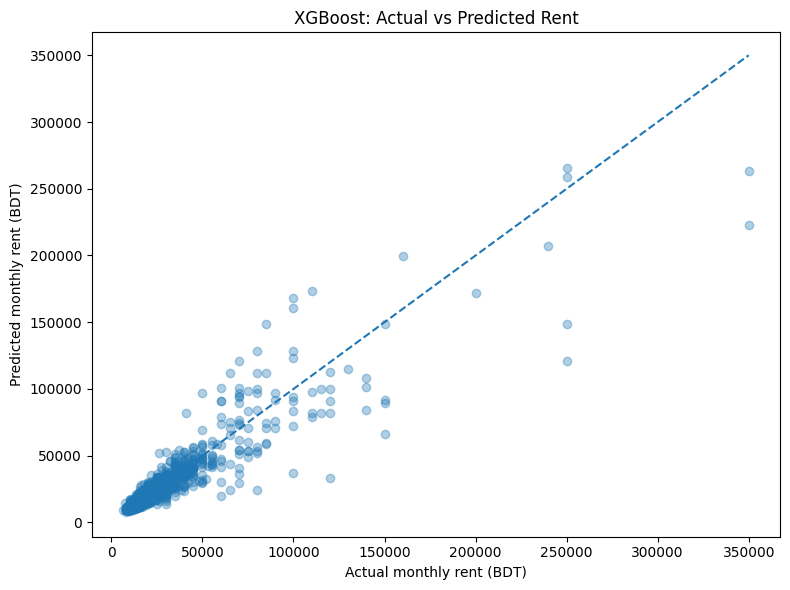

Saved: /content/drive/MyDrive/DhakaNest_ML/reports/figures/xgboost/actual_vs_predicted.png


In [38]:
plt.figure(figsize=(8, 6))

plt.scatter(
    validation_results_df[
        "base_rent_bdt"
    ],
    validation_results_df[
        "predicted_rent_bdt"
    ],
    alpha=0.35,
)

minimum_value = min(
    validation_results_df[
        "base_rent_bdt"
    ].min(),
    validation_results_df[
        "predicted_rent_bdt"
    ].min(),
)

maximum_value = max(
    validation_results_df[
        "base_rent_bdt"
    ].max(),
    validation_results_df[
        "predicted_rent_bdt"
    ].max(),
)

plt.plot(
    [minimum_value, maximum_value],
    [minimum_value, maximum_value],
    linestyle="--",
)

plt.xlabel("Actual monthly rent (BDT)")
plt.ylabel("Predicted monthly rent (BDT)")
plt.title("XGBoost: Actual vs Predicted Rent")
plt.tight_layout()

ACTUAL_PREDICTED_FIGURE_PATH = (
    XGB_FIGURES_DIR
    / "actual_vs_predicted.png"
)

plt.savefig(
    ACTUAL_PREDICTED_FIGURE_PATH,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print(
    "Saved:",
    ACTUAL_PREDICTED_FIGURE_PATH,
)

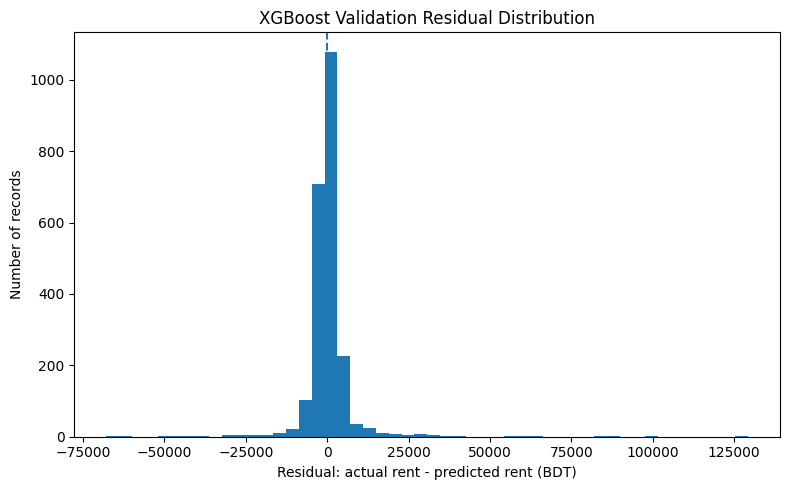

Saved: /content/drive/MyDrive/DhakaNest_ML/reports/figures/xgboost/validation_residual_distribution.png


In [39]:
plt.figure(figsize=(8, 5))

plt.hist(
    validation_results_df[
        "residual_bdt"
    ],
    bins=50,
)

plt.axvline(
    0,
    linestyle="--",
)

plt.xlabel(
    "Residual: actual rent - predicted rent (BDT)"
)

plt.ylabel("Number of records")

plt.title(
    "XGBoost Validation Residual Distribution"
)

plt.tight_layout()

RESIDUAL_FIGURE_PATH = (
    XGB_FIGURES_DIR
    / "validation_residual_distribution.png"
)

plt.savefig(
    RESIDUAL_FIGURE_PATH,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print("Saved:", RESIDUAL_FIGURE_PATH)

In [40]:
largest_errors_df = (
    validation_results_df.sort_values(
        "absolute_error_bdt",
        ascending=False,
    )
    .head(30)
)

display(
    largest_errors_df[
        [
            "record_id",
            "location_raw",
            "area_sqft",
            "bedrooms",
            "bathrooms",
            "base_rent_bdt",
            "predicted_rent_bdt",
            "absolute_error_bdt",
            "absolute_percentage_error",
        ]
    ]
)

LARGEST_ERRORS_PATH = (
    METRICS_DIR
    / "xgboost_largest_validation_errors.csv"
)

largest_errors_df.to_csv(
    LARGEST_ERRORS_PATH,
    index=False,
)

print("Saved:", LARGEST_ERRORS_PATH)

,record_id,location_raw,area_sqft,bedrooms,bathrooms,base_rent_bdt,predicted_rent_bdt,absolute_error_bdt,absolute_percentage_error
23,DN-000182,"Gulshan 2, Gulshan, Dhaka",2800,4,4,250000,120723.490302,129276.509698,51.710604
222,DN-001737,"Baridhara, Dhaka",3850,3,3,350000,223128.990163,126871.009837,36.248860
1634,DN-018936,"Gulshan 2, Gulshan, Dhaka",3200,4,4,250000,148504.980393,101495.019607,40.598008
1446,DN-016537,"Baridhara, Dhaka",4550,4,4,350000,263169.764566,86830.235434,24.808639
50,DN-000388,"Block A, Bashundhara R-A, Dhaka",1450,3,3,120000,33397.410243,86602.589757,72.168825
81,DN-000598,"Mohakhali DOHS, Dhaka",2750,3,3,150000,66634.371171,83365.628829,55.577086
127,DN-001023,"Gulshan 1, Gulshan, Dhaka",3500,4,4,100000,167803.320022,67803.320022,67.803320
1421,DN-016172,"Gulshan 2, Gulshan, Dhaka",3267,4,4,85000,148504.980393,63504.980393,74.711742
89,DN-000672,"Block K, Baridhara, Dhaka",2800,3,3,110000,173357.672890,63357.672890,57.597884
2050,DN-024851,"Avenue 6, Mirpur DOHS, Mirpur, Dhaka",2200,3,3,100000,36918.731891,63081.268109,63.081268


Saved: /content/drive/MyDrive/DhakaNest_ML/reports/metrics/xgboost_largest_validation_errors.csv


In [41]:
validation_results_df[
    "micro_area_support_level"
] = pd.cut(
    validation_results_df[
        "micro_area_support_count"
    ],
    bins=[
        -np.inf,
        29,
        99,
        np.inf,
    ],
    labels=[
        "low",
        "normal",
        "high",
    ],
)

validation_results_df["rent_range"] = pd.cut(
    validation_results_df[
        "base_rent_bdt"
    ],
    bins=[
        -np.inf,
        15_000,
        30_000,
        60_000,
        np.inf,
    ],
    labels=[
        "below_15000",
        "15000_to_30000",
        "30001_to_60000",
        "above_60000",
    ],
)

validation_results_df["area_range"] = pd.cut(
    validation_results_df["area_sqft"],
    bins=[
        -np.inf,
        700,
        1000,
        1500,
        2500,
        np.inf,
    ],
    labels=[
        "up_to_700",
        "701_to_1000",
        "1001_to_1500",
        "1501_to_2500",
        "above_2500",
    ],
)

print("Evaluation segments created.")

Evaluation segments created.


In [42]:
def calculate_segment_metrics(
    dataframe,
    segment_column,
):
    rows = []

    for segment_value, group in dataframe.groupby(
        segment_column,
        dropna=False,
        observed=False,
    ):
        if len(group) == 0:
            continue

        metrics = calculate_regression_metrics(
            group["base_rent_bdt"],
            group["predicted_rent_bdt"],
        )

        rows.append({
            "segment": str(segment_value),
            "record_count": int(len(group)),
            **metrics,
        })

    return (
        pd.DataFrame(rows)
        .sort_values(
            "mae_bdt",
            ascending=False,
        )
        .reset_index(drop=True)
    )

In [43]:
segment_definitions = {
    "broad_area": "broad_area",
    "model_micro_area": "model_micro_area",
    "micro_area_support": (
        "micro_area_support_level"
    ),
    "bedroom_count": "bedrooms",
    "bathroom_count": "bathrooms",
    "rent_range": "rent_range",
    "area_range": "area_range",
}

segment_result_tables = {}

for output_name, segment_column in (
    segment_definitions.items()
):
    result_df = calculate_segment_metrics(
        validation_results_df,
        segment_column,
    )

    segment_result_tables[
        output_name
    ] = result_df

    output_path = (
        SEGMENT_DIR
        / f"xgboost_by_{output_name}.csv"
    )

    result_df.to_csv(
        output_path,
        index=False,
    )

    print("\nSegment:", output_name)
    display(result_df.head(20))
    print("Saved:", output_path)


Segment: broad_area


,segment,record_count,mae_bdt,rmse_bdt,r2,mape_percent,median_absolute_error_bdt,p90_absolute_error_bdt
0,Baridhara,13,46006.696731,56849.282632,0.715439,36.038718,41302.006591,82135.722926
1,Mohakhali DOHS,3,37679.427306,50964.908393,-0.240280,32.863554,29017.377664,72495.978596
2,Gulshan,34,32213.463456,42062.467284,0.430830,33.216106,26781.806461,62674.370425
3,Banani,16,17510.496766,21322.700769,0.064182,20.917444,16098.941762,31168.611514
4,Baridhara DOHS,8,16642.988903,22786.941420,0.470833,24.272925,10770.225379,31440.990479
5,Banglamotors,1,10684.216829,10684.216829,NaN,35.614056,10684.216829,10684.216829
6,Banani DOHS,2,9689.852092,10943.328690,0.808390,8.560527,9689.852092,13758.322802
7,Turag,1,7824.984233,7824.984233,NaN,39.124921,7824.984233,7824.984233
8,Demra,1,7173.272795,7173.272795,NaN,95.643637,7173.272795,7173.272795
9,Paribagh,1,6820.040263,6820.040263,NaN,21.312626,6820.040263,6820.040263


Saved: /content/drive/MyDrive/DhakaNest_ML/reports/segment_evaluation/xgboost_by_broad_area.csv

Segment: model_micro_area


,segment,record_count,mae_bdt,rmse_bdt,r2,mape_percent,median_absolute_error_bdt,p90_absolute_error_bdt
0,Baridhara,5,59245.286244,72780.738657,0.613242,31.250306,46979.661106,110854.700076
1,Block K,5,47618.393727,49160.364992,0.456198,51.542930,41302.006591,62408.119917
2,Gulshan 2,18,38212.292070,50336.820242,0.365474,32.473039,30127.818224,74901.992157
3,OTHER_MOHAKHALI_DOHS,3,37679.427306,50964.908393,-0.240280,32.863554,29017.377664,72495.978596
4,Gulshan 1,16,25464.781265,30151.928567,0.246310,34.052057,25728.511615,43882.496013
5,OTHER_BARIDHARA,3,21256.219218,33887.289343,0.606281,18.179055,2635.932719,47390.930890
6,Banani,16,17510.496766,21322.700769,0.064182,20.917444,16098.941762,31168.611514
7,Baridhara DOHS,8,16642.988903,22786.941420,0.470833,24.272925,10770.225379,31440.990479
8,OTHER_BANGLAMOTORS,1,10684.216829,10684.216829,NaN,35.614056,10684.216829,10684.216829
9,Block A,13,10646.164695,24579.689388,0.031223,18.133975,4574.922533,10396.195680


Saved: /content/drive/MyDrive/DhakaNest_ML/reports/segment_evaluation/xgboost_by_model_micro_area.csv

Segment: micro_area_support


...

Saved: /content/drive/MyDrive/DhakaNest_ML/reports/segment_evaluation/xgboost_by_bathroom_count.csv

Segment: rent_range


,segment,record_count,mae_bdt,rmse_bdt,r2,mape_percent,median_absolute_error_bdt,p90_absolute_error_bdt
0,above_60000,85,31072.825304,40592.926425,0.519835,29.263352,25100.357822,63247.110978
1,30001_to_60000,234,6689.653346,9847.992677,-0.643498,15.711814,4566.961543,14156.456091
2,15000_to_30000,1059,2564.420397,3531.632630,0.320485,11.853594,1967.584653,5326.325828
3,below_15000,911,1375.456005,1818.867746,0.029095,11.317730,1092.029542,2831.722742


Saved: /content/drive/MyDrive/DhakaNest_ML/reports/segment_evaluation/xgboost_by_rent_range.csv

Segment: area_range


,segment,record_count,mae_bdt,rmse_bdt,r2,mape_percent,median_absolute_error_bdt,p90_absolute_error_bdt
0,above_2500,57,31058.925721,42790.119622,0.618271,25.897378,23506.189238,65224.316245
1,1501_to_2500,298,7646.945111,12144.972318,0.574749,18.026365,4282.907559,18501.303888
2,1001_to_1500,757,3000.858894,5589.156241,0.511857,12.425211,2034.856179,5838.073175
3,701_to_1000,640,1806.301768,2917.722457,0.508511,11.177347,1413.539065,3456.210086
4,up_to_700,537,1300.742890,1704.468860,0.581855,10.465481,1030.800853,2875.527814


Saved: /content/drive/MyDrive/DhakaNest_ML/reports/segment_evaluation/xgboost_by_area_range.csv


In [44]:
encoded_feature_names = (
    final_preprocessor.get_feature_names_out()
)

ENCODED_FEATURE_NAMES_PATH = (
    XGB_ARTIFACT_DIR
    / "encoded_feature_names.csv"
)

pd.DataFrame({
    "feature": encoded_feature_names
}).to_csv(
    ENCODED_FEATURE_NAMES_PATH,
    index=False,
)

print(
    "Encoded feature count:",
    len(encoded_feature_names),
)

print(
    "Saved:",
    ENCODED_FEATURE_NAMES_PATH,
)

Encoded feature count: 268
Saved: /content/drive/MyDrive/DhakaNest_ML/artifacts/candidates/xgboost/encoded_feature_names.csv


In [45]:
feature_importance_df = pd.DataFrame({
    "feature": encoded_feature_names,
    "importance": (
        chosen_model.feature_importances_
    ),
}).sort_values(
    "importance",
    ascending=False,
)

FEATURE_IMPORTANCE_PATH = (
    METRICS_DIR
    / "xgboost_feature_importance.csv"
)

feature_importance_df.to_csv(
    FEATURE_IMPORTANCE_PATH,
    index=False,
)

display(feature_importance_df.head(30))

print("Saved:", FEATURE_IMPORTANCE_PATH)

,feature,importance
18,categorical__broad_area_Gulshan,0.062165
9,categorical__broad_area_Baridhara,0.052060
265,numerical__area_sqft,0.036540
267,numerical__bathrooms,0.036211
40,categorical__broad_area_Mirpur,0.028905
4,categorical__broad_area_Banani,0.021771
13,categorical__broad_area_Cantonment,0.021670
14,categorical__broad_area_Dakshin Khan,0.020129
77,categorical__model_micro_area_Banani,0.018276
43,categorical__broad_area_Mohammadpur,0.016676


Saved: /content/drive/MyDrive/DhakaNest_ML/reports/metrics/xgboost_feature_importance.csv


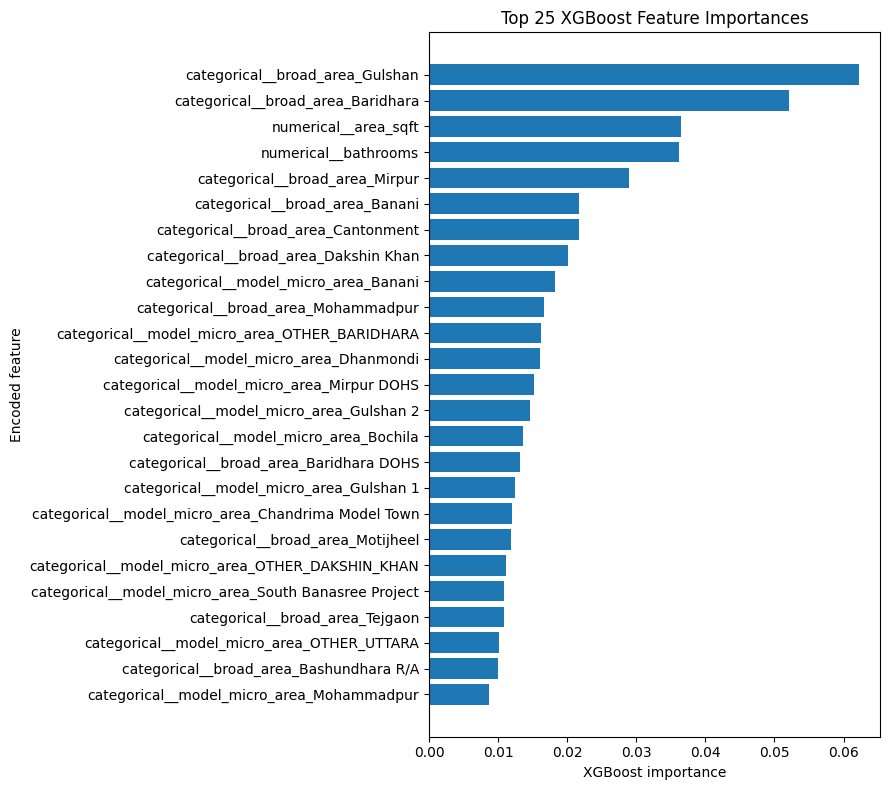

Saved: /content/drive/MyDrive/DhakaNest_ML/reports/figures/xgboost/feature_importance_top_25.png


In [46]:
top_feature_importance_df = (
    feature_importance_df.head(25)
    .sort_values(
        "importance",
        ascending=True,
    )
)

plt.figure(figsize=(9, 8))

plt.barh(
    top_feature_importance_df[
        "feature"
    ],
    top_feature_importance_df[
        "importance"
    ],
)

plt.xlabel("XGBoost importance")
plt.ylabel("Encoded feature")
plt.title("Top 25 XGBoost Feature Importances")
plt.tight_layout()

FEATURE_IMPORTANCE_FIGURE_PATH = (
    XGB_FIGURES_DIR
    / "feature_importance_top_25.png"
)

plt.savefig(
    FEATURE_IMPORTANCE_FIGURE_PATH,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print(
    "Saved:",
    FEATURE_IMPORTANCE_FIGURE_PATH,
)

## Unseen Micro-Area Challenge

The selected XGBoost configuration is retrained on the challenge-training
subset using the selected number of boosting rounds. Complete micro-areas
held outside that subset are then evaluated.

In [47]:
chosen_best_iteration = getattr(
    chosen_model,
    "best_iteration",
    None,
)

if chosen_best_iteration is not None:
    effective_n_estimators = (
        int(chosen_best_iteration) + 1
    )
else:
    effective_n_estimators = int(
        searched_n_estimators
    )

print(
    "Boosting rounds used for challenge models:",
    effective_n_estimators,
)

Boosting rounds used for challenge models: 468


In [48]:
def train_and_evaluate_challenge_model(
    training_dataframe,
    challenge_dataframe,
    feature_columns,
    categorical_features,
    numerical_features,
    target_strategy,
):
    challenge_preprocessor = (
        create_preprocessor(
            categorical_features=(
                categorical_features
            ),
            numerical_features=(
                numerical_features
            ),
        )
    )

    X_challenge_train = (
        challenge_preprocessor.fit_transform(
            training_dataframe[
                feature_columns
            ]
        )
    )

    X_challenge_evaluation = (
        challenge_preprocessor.transform(
            challenge_dataframe[
                feature_columns
            ]
        )
    )

    y_challenge_train = (
        training_dataframe[
            TARGET_COLUMN
        ].to_numpy()
    )

    y_challenge_evaluation = (
        challenge_dataframe[
            TARGET_COLUMN
        ].to_numpy()
    )

    if target_strategy == "log1p":
        fitted_target = np.log1p(
            y_challenge_train
        )
    else:
        fitted_target = y_challenge_train

    challenge_model = xgb.XGBRegressor(
        objective="reg:squarederror",
        n_estimators=effective_n_estimators,
        tree_method="hist",
        eval_metric="mae",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=0,
        **best_search_parameters,
    )

    training_start = perf_counter()

    challenge_model.fit(
        X_challenge_train,
        fitted_target,
        verbose=False,
    )

    training_seconds = (
        perf_counter() - training_start
    )

    metrics, predictions = (
        evaluate_encoded_xgb_model(
            challenge_model,
            X_challenge_evaluation,
            y_challenge_evaluation,
            target_strategy,
        )
    )

    metrics[
        "training_time_seconds"
    ] = float(training_seconds)

    return {
        "preprocessor": challenge_preprocessor,
        "model": challenge_model,
        "metrics": metrics,
        "predictions": predictions,
    }

In [49]:
unseen_primary_result = (
    train_and_evaluate_challenge_model(
        training_dataframe=unseen_train_df,
        challenge_dataframe=(
            unseen_challenge_df
        ),
        feature_columns=FEATURE_COLUMNS,
        categorical_features=(
            CATEGORICAL_FEATURES
        ),
        numerical_features=(
            NUMERICAL_FEATURES
        ),
        target_strategy=(
            chosen_target_strategy
        ),
    )
)

unseen_primary_metrics = (
    unseen_primary_result["metrics"]
)

print(
    "Primary pipeline unseen-location metrics:"
)

display(
    pd.DataFrame(
        [unseen_primary_metrics]
    )
)

Primary pipeline unseen-location metrics:


,mae_bdt,rmse_bdt,r2,mape_percent,median_absolute_error_bdt,p90_absolute_error_bdt,prediction_time_seconds,milliseconds_per_record,training_time_seconds
0,2770.12879,3917.089718,0.671341,15.196742,1990.46364,6208.126803,0.010537,0.009416,0.386517


In [50]:
BROAD_FALLBACK_FEATURES = [
    "broad_area",
    "area_sqft",
    "bedrooms",
    "bathrooms",
]

broad_fallback_result = (
    train_and_evaluate_challenge_model(
        training_dataframe=unseen_train_df,
        challenge_dataframe=(
            unseen_challenge_df
        ),
        feature_columns=(
            BROAD_FALLBACK_FEATURES
        ),
        categorical_features=[
            "broad_area"
        ],
        numerical_features=(
            NUMERICAL_FEATURES
        ),
        target_strategy=(
            chosen_target_strategy
        ),
    )
)

broad_fallback_metrics = (
    broad_fallback_result["metrics"]
)

print("Broad-area fallback metrics:")

display(
    pd.DataFrame(
        [broad_fallback_metrics]
    )
)

Broad-area fallback metrics:


,mae_bdt,rmse_bdt,r2,mape_percent,median_absolute_error_bdt,p90_absolute_error_bdt,prediction_time_seconds,milliseconds_per_record,training_time_seconds
0,2797.79845,3984.082334,0.660003,15.359791,1953.801678,6205.869574,0.013075,0.011685,0.347385


In [51]:
DHAKA_WIDE_FEATURES = [
    "area_sqft",
    "bedrooms",
    "bathrooms",
]

dhaka_wide_result = (
    train_and_evaluate_challenge_model(
        training_dataframe=unseen_train_df,
        challenge_dataframe=(
            unseen_challenge_df
        ),
        feature_columns=(
            DHAKA_WIDE_FEATURES
        ),
        categorical_features=[],
        numerical_features=(
            NUMERICAL_FEATURES
        ),
        target_strategy=(
            chosen_target_strategy
        ),
    )
)

dhaka_wide_metrics = (
    dhaka_wide_result["metrics"]
)

print("Dhaka-wide fallback metrics:")

display(
    pd.DataFrame(
        [dhaka_wide_metrics]
    )
)

Dhaka-wide fallback metrics:


,mae_bdt,rmse_bdt,r2,mape_percent,median_absolute_error_bdt,p90_absolute_error_bdt,prediction_time_seconds,milliseconds_per_record,training_time_seconds
0,3055.308026,4602.527367,0.546256,17.007996,2152.556468,6685.913964,0.019592,0.017508,0.803356


In [52]:
unseen_comparison_df = pd.DataFrame([
    {
        "strategy": (
            "primary_pipeline_unknown_micro_area"
        ),
        **unseen_primary_metrics,
    },
    {
        "strategy": (
            "broad_area_fallback"
        ),
        **broad_fallback_metrics,
    },
    {
        "strategy": (
            "dhaka_wide_fallback"
        ),
        **dhaka_wide_metrics,
    },
]).sort_values(
    "mae_bdt",
    ascending=True,
)

UNSEEN_COMPARISON_PATH = (
    METRICS_DIR
    / "xgboost_unseen_location_comparison.csv"
)

unseen_comparison_df.to_csv(
    UNSEEN_COMPARISON_PATH,
    index=False,
)

display(unseen_comparison_df)

print("Saved:", UNSEEN_COMPARISON_PATH)

,strategy,mae_bdt,rmse_bdt,r2,mape_percent,median_absolute_error_bdt,p90_absolute_error_bdt,prediction_time_seconds,milliseconds_per_record,training_time_seconds
0,primary_pipeline_unknown_micro_area,2770.128790,3917.089718,0.671341,15.196742,1990.463640,6208.126803,0.010537,0.009416,0.386517
1,broad_area_fallback,2797.798450,3984.082334,0.660003,15.359791,1953.801678,6205.869574,0.013075,0.011685,0.347385
2,dhaka_wide_fallback,3055.308026,4602.527367,0.546256,17.007996,2152.556468,6685.913964,0.019592,0.017508,0.803356


Saved: /content/drive/MyDrive/DhakaNest_ML/reports/metrics/xgboost_unseen_location_comparison.csv


In [53]:
best_parameters_export = {
    "search_best_parameters": (
        search.best_params_
    ),
    "best_core_parameters": (
        best_search_parameters
    ),
    "searched_n_estimators": int(
        searched_n_estimators
    ),
    "final_max_estimators": (
        MAX_FINAL_ESTIMATORS
    ),
    "early_stopping_rounds": (
        EARLY_STOPPING_ROUNDS
    ),
    "selected_best_iteration": int(
        chosen_model.best_iteration
    ),
    "selected_effective_estimators": int(
        chosen_model.best_iteration + 1
    ),
    "target_strategy": (
        chosen_target_strategy
    ),
}

BEST_PARAMETERS_PATH = (
    XGB_ARTIFACT_DIR
    / "best_parameters.json"
)

with BEST_PARAMETERS_PATH.open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        best_parameters_export,
        file,
        indent=2,
    )

print("Saved:", BEST_PARAMETERS_PATH)

Saved: /content/drive/MyDrive/DhakaNest_ML/artifacts/candidates/xgboost/best_parameters.json


In [54]:
feature_schema = {
    "model_name": "XGBoost Regressor",
    "candidate_version": "1.0.0",
    "categorical_features": (
        CATEGORICAL_FEATURES
    ),
    "numerical_features": (
        NUMERICAL_FEATURES
    ),
    "feature_order": FEATURE_COLUMNS,
    "target_column": TARGET_COLUMN,
    "target_strategy": (
        chosen_target_strategy
    ),
    "currency": "BDT",
    "input_rules": {
        "broad_area": "normalized text",
        "model_micro_area": (
            "supported normalized micro-area "
            "or OTHER_<BROAD_AREA>"
        ),
        "area_sqft": (
            "positive numeric value"
        ),
        "bedrooms": (
            "positive integer"
        ),
        "bathrooms": (
            "positive integer"
        ),
    },
}

FEATURE_SCHEMA_PATH = (
    XGB_ARTIFACT_DIR
    / "feature_schema.json"
)

with FEATURE_SCHEMA_PATH.open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        feature_schema,
        file,
        indent=2,
    )

print("Saved:", FEATURE_SCHEMA_PATH)

Saved: /content/drive/MyDrive/DhakaNest_ML/artifacts/candidates/xgboost/feature_schema.json


In [55]:
PREPROCESSOR_PATH = (
    XGB_ARTIFACT_DIR
    / "preprocessor.joblib"
)

joblib.dump(
    final_preprocessor,
    PREPROCESSOR_PATH,
    compress=3,
)

print("Saved:", PREPROCESSOR_PATH)

print(
    "Preprocessor size in MB:",
    round(
        PREPROCESSOR_PATH.stat().st_size
        / (1024 ** 2),
        3,
    ),
)

Saved: /content/drive/MyDrive/DhakaNest_ML/artifacts/candidates/xgboost/preprocessor.joblib
Preprocessor size in MB: 0.003


In [56]:
MODEL_JSON_PATH = (
    XGB_ARTIFACT_DIR
    / "xgboost_model.json"
)

chosen_model.save_model(
    str(MODEL_JSON_PATH)
)

print("Saved:", MODEL_JSON_PATH)

print(
    "Model size in MB:",
    round(
        MODEL_JSON_PATH.stat().st_size
        / (1024 ** 2),
        3,
    ),
)

Saved: /content/drive/MyDrive/DhakaNest_ML/artifacts/candidates/xgboost/xgboost_model.json
Model size in MB: 1.407


In [57]:
sample_input = {
    "broad_area": str(
        validation_df.iloc[0][
            "broad_area"
        ]
    ),
    "model_micro_area": str(
        validation_df.iloc[0][
            "model_micro_area"
        ]
    ),
    "area_sqft": int(
        validation_df.iloc[0][
            "area_sqft"
        ]
    ),
    "bedrooms": int(
        validation_df.iloc[0][
            "bedrooms"
        ]
    ),
    "bathrooms": int(
        validation_df.iloc[0][
            "bathrooms"
        ]
    ),
}

SAMPLE_INPUT_PATH = (
    XGB_ARTIFACT_DIR
    / "sample_input.json"
)

with SAMPLE_INPUT_PATH.open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        sample_input,
        file,
        indent=2,
    )

print(json.dumps(sample_input, indent=2))
print("Saved:", SAMPLE_INPUT_PATH)

{
  "broad_area": "Gulshan",
  "model_micro_area": "Gulshan 1",
  "area_sqft": 2200,
  "bedrooms": 3,
  "bathrooms": 4
}
Saved: /content/drive/MyDrive/DhakaNest_ML/artifacts/candidates/xgboost/sample_input.json


In [58]:
xgboost_metrics = {
    "model_name": "XGBoost",
    "candidate_version": "1.0.0",
    "target_strategy": (
        chosen_target_strategy
    ),
    "dummy_baseline": {
        "train": dummy_train_metrics,
        "validation": (
            dummy_validation_metrics
        ),
        "training_time_seconds": (
            dummy_training_time
        ),
    },
    "initial_xgboost": {
        "train": initial_train_metrics,
        "validation": (
            initial_validation_metrics
        ),
        "training_time_seconds": (
            initial_training_time
        ),
    },
    "tuned_raw_target": {
        "train": raw_train_metrics,
        "validation": (
            raw_validation_metrics
        ),
        "training_time_seconds": (
            raw_training_time
        ),
        "best_iteration": int(
            raw_xgb_model.best_iteration
        ),
    },
    "tuned_log_target": {
        "train": log_train_metrics,
        "validation": (
            log_validation_metrics
        ),
        "training_time_seconds": (
            log_training_time
        ),
        "best_iteration": int(
            log_xgb_model.best_iteration
        ),
    },
    "chosen_candidate": {
        "train": chosen_train_metrics,
        "validation": (
            chosen_validation_metrics
        ),
        "best_iteration": int(
            chosen_model.best_iteration
        ),
    },
    "unseen_location_challenge": {
        "primary_pipeline": (
            unseen_primary_metrics
        ),
        "broad_area_fallback": (
            broad_fallback_metrics
        ),
        "dhaka_wide_fallback": (
            dhaka_wide_metrics
        ),
    },
    "test_evaluation": None,
    "test_status": (
        "Untouched until final "
        "algorithm selection"
    ),
}

METRICS_JSON_PATH = (
    XGB_ARTIFACT_DIR / "metrics.json"
)

REPORT_METRICS_PATH = (
    METRICS_DIR
    / "xgboost_metrics.json"
)

for path in [
    METRICS_JSON_PATH,
    REPORT_METRICS_PATH,
]:
    with path.open(
        "w",
        encoding="utf-8",
    ) as file:
        json.dump(
            xgboost_metrics,
            file,
            indent=2,
        )

    print("Saved:", path)

Saved: /content/drive/MyDrive/DhakaNest_ML/artifacts/candidates/xgboost/metrics.json
Saved: /content/drive/MyDrive/DhakaNest_ML/reports/metrics/xgboost_metrics.json


In [59]:
reloaded_preprocessor = joblib.load(
    PREPROCESSOR_PATH
)

reloaded_xgb_model = xgb.XGBRegressor()

reloaded_xgb_model.load_model(
    str(MODEL_JSON_PATH)
)

sample_input_df = pd.DataFrame(
    [sample_input],
    columns=FEATURE_COLUMNS,
)

sample_encoded_original = (
    final_preprocessor.transform(
        sample_input_df
    )
)

sample_encoded_reloaded = (
    reloaded_preprocessor.transform(
        sample_input_df
    )
)

prediction_before_reload = (
    convert_predictions_to_bdt(
        chosen_model.predict(
            sample_encoded_original
        ),
        chosen_target_strategy,
    )[0]
)

prediction_after_reload = (
    convert_predictions_to_bdt(
        reloaded_xgb_model.predict(
            sample_encoded_reloaded
        ),
        chosen_target_strategy,
    )[0]
)

print(
    "Prediction before reload:",
    prediction_before_reload,
)

print(
    "Prediction after reload:",
    prediction_after_reload,
)

assert np.isclose(
    prediction_before_reload,
    prediction_after_reload,
    rtol=0,
    atol=1e-6,
), "Prediction changed after artifact reload."

print("Artifact reload verification passed.")

Prediction before reload: 71069.64306369255
Prediction after reload: 71069.64306369255
Artifact reload verification passed.


In [60]:
reload_test_X = X_validation.head(20)

original_encoded = (
    final_preprocessor.transform(
        reload_test_X
    )
)

reloaded_encoded = (
    reloaded_preprocessor.transform(
        reload_test_X
    )
)

original_predictions = (
    convert_predictions_to_bdt(
        chosen_model.predict(
            original_encoded
        ),
        chosen_target_strategy,
    )
)

reloaded_predictions = (
    convert_predictions_to_bdt(
        reloaded_xgb_model.predict(
            reloaded_encoded
        ),
        chosen_target_strategy,
    )
)

assert np.allclose(
    original_predictions,
    reloaded_predictions,
    rtol=0,
    atol=1e-6,
), "Reloaded predictions do not match."

print(
    "All 20 reload-test predictions matched."
)

All 20 reload-test predictions matched.


In [61]:
def calculate_sha256(file_path):
    sha256 = hashlib.sha256()

    with Path(file_path).open("rb") as file:
        for block in iter(
            lambda: file.read(
                1024 * 1024
            ),
            b"",
        ):
            sha256.update(block)

    return sha256.hexdigest()

In [62]:
model_manifest = {
    "project_name": "DhakaNest",
    "model_name": "XGBoost",
    "candidate_version": "1.0.0",
    "created_at_utc": datetime.now(
        timezone.utc
    ).isoformat(),
    "xgboost_version": xgb.__version__,
    "target_strategy": (
        chosen_target_strategy
    ),
    "feature_columns": FEATURE_COLUMNS,
    "target_column": TARGET_COLUMN,
    "training_rows": int(
        len(train_df)
    ),
    "validation_rows": int(
        len(validation_df)
    ),
    "test_rows_used": 0,
    "random_state": RANDOM_STATE,
    "cross_validation": {
        "method": "GroupKFold",
        "folds": 5,
        "search_method": (
            "RandomizedSearchCV"
        ),
        "search_iterations": 18,
        "selection_metric": (
            "negative mean absolute error"
        ),
    },
    "early_stopping": {
        "maximum_estimators": (
            MAX_FINAL_ESTIMATORS
        ),
        "early_stopping_rounds": (
            EARLY_STOPPING_ROUNDS
        ),
        "selected_best_iteration": int(
            chosen_model.best_iteration
        ),
    },
    "best_parameters": (
        best_parameters_export
    ),
    "validation_metrics": (
        chosen_validation_metrics
    ),
    "artifact_files": {
        "native_model": (
            MODEL_JSON_PATH.name
        ),
        "preprocessor": (
            PREPROCESSOR_PATH.name
        ),
        "metrics": (
            METRICS_JSON_PATH.name
        ),
        "feature_schema": (
            FEATURE_SCHEMA_PATH.name
        ),
        "sample_input": (
            SAMPLE_INPUT_PATH.name
        ),
        "encoded_feature_names": (
            ENCODED_FEATURE_NAMES_PATH.name
        ),
    },
    "checksums": {
        "native_model_sha256": (
            calculate_sha256(
                MODEL_JSON_PATH
            )
        ),
        "preprocessor_sha256": (
            calculate_sha256(
                PREPROCESSOR_PATH
            )
        ),
    },
    "artifact_reload_verified": True,
    "test_status": (
        "Official test set remains untouched."
    ),
}

MODEL_MANIFEST_PATH = (
    XGB_ARTIFACT_DIR
    / "model_manifest.json"
)

with MODEL_MANIFEST_PATH.open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        model_manifest,
        file,
        indent=2,
    )

print("Saved:", MODEL_MANIFEST_PATH)

Saved: /content/drive/MyDrive/DhakaNest_ML/artifacts/candidates/xgboost/model_manifest.json


In [63]:
model_card = f"""# DhakaNest XGBoost Candidate

## Model

- Algorithm: XGBoost Regressor
- Candidate version: 1.0.0
- XGBoost version: {xgb.__version__}
- Target strategy: {chosen_target_strategy}
- Random state: {RANDOM_STATE}
- Best iteration: {chosen_model.best_iteration}

## Inputs

- Broad area
- Model micro-area
- Area in square feet
- Number of bedrooms
- Number of bathrooms

## Target

Monthly base rent in BDT.

## Dataset

- Training rows: {len(train_df):,}
- Validation rows: {len(validation_df):,}
- Test rows used during candidate development: 0

## Validation Performance

- MAE: BDT {chosen_validation_metrics["mae_bdt"]:,.2f}
- RMSE: BDT {chosen_validation_metrics["rmse_bdt"]:,.2f}
- R²: {chosen_validation_metrics["r2"]:.4f}
- MAPE: {chosen_validation_metrics["mape_percent"]:.2f}%
- Median absolute error:
  BDT {chosen_validation_metrics["median_absolute_error_bdt"]:,.2f}
- P90 absolute error:
  BDT {chosen_validation_metrics["p90_absolute_error_bdt"]:,.2f}

## Development Method

Hyperparameters were selected using RandomizedSearchCV with five-fold
GroupKFold cross-validation. The final raw-target and log-target candidates
were trained with validation-based early stopping.

## Unseen Locations

The model was separately evaluated using complete micro-areas excluded from
a challenge-training subset. Broad-area and Dhaka-wide fallback approaches
were also evaluated.

## Export

The fitted XGBoost model is saved in native JSON format. The scikit-learn
preprocessor is saved separately using joblib. The target transformation
strategy is stored in the feature schema and manifest.

## Limitations

- The source data does not include listing IDs, exact coordinates,
  furnishing, facilities, service charges, or listing dates.
- The quality of location-based prediction depends on location normalization.
- Predictions represent historical base-rent patterns from the supplied data.
- The official untouched test dataset has not yet been evaluated.
- The candidate must be compared with Random Forest and CatBoost before final
  selection.

## Deployment Status

Candidate artifacts were exported and successfully reloaded. The model is not
yet approved as the final production algorithm.
"""

MODEL_CARD_PATH = (
    XGB_ARTIFACT_DIR
    / "model_card.md"
)

MODEL_CARD_PATH.write_text(
    model_card,
    encoding="utf-8",
)

print("Saved:", MODEL_CARD_PATH)

Saved: /content/drive/MyDrive/DhakaNest_ML/artifacts/candidates/xgboost/model_card.md


In [64]:
required_xgboost_outputs = [
    MODEL_JSON_PATH,
    PREPROCESSOR_PATH,
    METRICS_JSON_PATH,
    BEST_PARAMETERS_PATH,
    FEATURE_SCHEMA_PATH,
    ENVIRONMENT_PATH,
    SAMPLE_INPUT_PATH,
    MODEL_MANIFEST_PATH,
    MODEL_CARD_PATH,
    ENCODED_FEATURE_NAMES_PATH,
    XGB_COMPARISON_PATH,
    CV_RESULTS_PATH,
    VALIDATION_PREDICTIONS_PATH,
    FEATURE_IMPORTANCE_PATH,
    UNSEEN_COMPARISON_PATH,
    ACTUAL_PREDICTED_FIGURE_PATH,
    RESIDUAL_FIGURE_PATH,
    FEATURE_IMPORTANCE_FIGURE_PATH,
    RAW_LEARNING_CURVE_PATH,
    LOG_LEARNING_CURVE_PATH,
]

missing_outputs = [
    str(path)
    for path in required_xgboost_outputs
    if not path.exists()
]

if missing_outputs:
    raise FileNotFoundError(
        "Missing XGBoost outputs:\n"
        + "\n".join(missing_outputs)
    )

assert MODEL_JSON_PATH.stat().st_size > 0
assert PREPROCESSOR_PATH.stat().st_size > 0

assert (
    chosen_validation_metrics[
        "mae_bdt"
    ] > 0
)

assert (
    chosen_validation_metrics[
        "rmse_bdt"
    ] > 0
)

print("=" * 70)
print("XGBOOST CANDIDATE COMPLETED SUCCESSFULLY")
print("=" * 70)

print(
    "Selected target strategy:",
    chosen_target_strategy,
)

print(
    "Best iteration:",
    chosen_model.best_iteration,
)

print(
    "Validation MAE:",
    round(
        chosen_validation_metrics[
            "mae_bdt"
        ],
        2,
    ),
)

print(
    "Validation RMSE:",
    round(
        chosen_validation_metrics[
            "rmse_bdt"
        ],
        2,
    ),
)

print(
    "Validation R²:",
    round(
        chosen_validation_metrics[
            "r2"
        ],
        4,
    ),
)

print(
    "Validation MAPE:",
    round(
        chosen_validation_metrics[
            "mape_percent"
        ],
        2,
    ),
)

print("Official test rows evaluated: 0")
print("Artifact reload verified: Yes")
print("All required files exist.")

XGBOOST CANDIDATE COMPLETED SUCCESSFULLY
Selected target strategy: log1p
Best iteration: 467
Validation MAE: 3571.57
Validation RMSE: 8842.54
Validation R²: 0.8415
Validation MAPE: 12.68
Official test rows evaluated: 0
Artifact reload verified: Yes
All required files exist.


In [65]:
summary_for_review = {
    "model": "XGBoost",
    "xgboost_version": (
        xgb.__version__
    ),
    "target_strategy": (
        chosen_target_strategy
    ),
    "training_rows": int(
        len(train_df)
    ),
    "validation_rows": int(
        len(validation_df)
    ),
    "dummy_validation_mae_bdt": round(
        dummy_validation_metrics[
            "mae_bdt"
        ],
        2,
    ),
    "initial_xgboost_validation_mae_bdt": round(
        initial_validation_metrics[
            "mae_bdt"
        ],
        2,
    ),
    "tuned_raw_validation_mae_bdt": round(
        raw_validation_metrics[
            "mae_bdt"
        ],
        2,
    ),
    "tuned_log_validation_mae_bdt": round(
        log_validation_metrics[
            "mae_bdt"
        ],
        2,
    ),
    "selected_validation_mae_bdt": round(
        chosen_validation_metrics[
            "mae_bdt"
        ],
        2,
    ),
    "selected_validation_rmse_bdt": round(
        chosen_validation_metrics[
            "rmse_bdt"
        ],
        2,
    ),
    "selected_validation_r2": round(
        chosen_validation_metrics[
            "r2"
        ],
        4,
    ),
    "selected_validation_mape_percent": round(
        chosen_validation_metrics[
            "mape_percent"
        ],
        2,
    ),
    "selected_validation_median_absolute_error_bdt": round(
        chosen_validation_metrics[
            "median_absolute_error_bdt"
        ],
        2,
    ),
    "selected_validation_p90_absolute_error_bdt": round(
        chosen_validation_metrics[
            "p90_absolute_error_bdt"
        ],
        2,
    ),
    "train_validation_mae_gap_bdt": round(
        chosen_validation_metrics[
            "mae_bdt"
        ]
        - chosen_train_metrics[
            "mae_bdt"
        ],
        2,
    ),
    "selected_best_iteration": int(
        chosen_model.best_iteration
    ),
    "unseen_primary_mae_bdt": round(
        unseen_primary_metrics[
            "mae_bdt"
        ],
        2,
    ),
    "broad_area_fallback_mae_bdt": round(
        broad_fallback_metrics[
            "mae_bdt"
        ],
        2,
    ),
    "dhaka_wide_fallback_mae_bdt": round(
        dhaka_wide_metrics[
            "mae_bdt"
        ],
        2,
    ),
    "best_parameters": (
        search.best_params_
    ),
    "artifact_reload_verified": True,
    "official_test_evaluated": False,
}

print(
    json.dumps(
        summary_for_review,
        indent=2,
    )
)

{
  "model": "XGBoost",
  "xgboost_version": "3.3.0",
  "target_strategy": "log1p",
  "training_rows": 10668,
  "validation_rows": 2289,
  "dummy_validation_mae_bdt": 9648.19,
  "initial_xgboost_validation_mae_bdt": 3648.65,
  "tuned_raw_validation_mae_bdt": 3683.36,
  "tuned_log_validation_mae_bdt": 3571.57,
  "selected_validation_mae_bdt": 3571.57,
  "selected_validation_rmse_bdt": 8842.54,
  "selected_validation_r2": 0.8415,
  "selected_validation_mape_percent": 12.68,
  "selected_validation_median_absolute_error_bdt": 1689.22,
  "selected_validation_p90_absolute_error_bdt": 6454.96,
  "train_validation_mae_gap_bdt": 471.41,
  "selected_best_iteration": 467,
  "unseen_primary_mae_bdt": 2770.13,
  "broad_area_fallback_mae_bdt": 2797.8,
  "dhaka_wide_fallback_mae_bdt": 3055.31,
  "best_parameters": {
    "model__subsample": 0.85,
    "model__reg_lambda": 1.0,
    "model__reg_alpha": 0.0,
    "model__n_estimators": 800,
    "model__min_child_weight": 10,
    "model__max_depth": 7,
    

In [66]:
from pathlib import Path

PROJECT_ROOT = Path("/content/drive/MyDrive/DhakaNest_ML")

files_to_check = [
    PROJECT_ROOT / "data/splits/train.csv",
    PROJECT_ROOT / "data/splits/validation.csv",
    PROJECT_ROOT / "data/splits/test.csv",
    PROJECT_ROOT / "data/splits/unseen_micro_area_train.csv",
    PROJECT_ROOT / "data/splits/unseen_micro_area_challenge.csv",

    PROJECT_ROOT / "artifacts/candidates/xgboost/xgboost_model.json",
    PROJECT_ROOT / "artifacts/candidates/xgboost/preprocessor.joblib",
    PROJECT_ROOT / "artifacts/candidates/xgboost/metrics.json",
    PROJECT_ROOT / "artifacts/candidates/xgboost/best_parameters.json",
    PROJECT_ROOT / "artifacts/candidates/xgboost/feature_schema.json",
    PROJECT_ROOT / "artifacts/candidates/xgboost/training_environment.json",
    PROJECT_ROOT / "artifacts/candidates/xgboost/sample_input.json",
    PROJECT_ROOT / "artifacts/candidates/xgboost/model_manifest.json",
    PROJECT_ROOT / "artifacts/candidates/xgboost/model_card.md",
    PROJECT_ROOT / "artifacts/candidates/xgboost/encoded_feature_names.csv",

    PROJECT_ROOT / "reports/metrics/xgboost_metrics.json",
    PROJECT_ROOT / "reports/metrics/xgboost_validation_comparison.csv",
    PROJECT_ROOT / "reports/metrics/xgboost_cv_results.csv",
    PROJECT_ROOT / "reports/metrics/xgboost_validation_predictions.csv",
    PROJECT_ROOT / "reports/metrics/xgboost_largest_validation_errors.csv",
    PROJECT_ROOT / "reports/metrics/xgboost_feature_importance.csv",
    PROJECT_ROOT / "reports/metrics/xgboost_unseen_location_comparison.csv",

    PROJECT_ROOT / "reports/figures/xgboost/actual_vs_predicted.png",
    PROJECT_ROOT / "reports/figures/xgboost/validation_residual_distribution.png",
    PROJECT_ROOT / "reports/figures/xgboost/feature_importance_top_25.png",
    PROJECT_ROOT / "reports/figures/xgboost/raw_target_learning_curve.png",
    PROJECT_ROOT / "reports/figures/xgboost/log_target_learning_curve.png",

    PROJECT_ROOT / "notebooks/02_DhakaNest_XGBoost.ipynb",
]

missing_files = []
empty_files = []

for path in files_to_check:
    if not path.exists():
        missing_files.append(str(path))
    elif path.is_file() and path.stat().st_size == 0:
        empty_files.append(str(path))

print("Files checked:", len(files_to_check))
print("Missing files:", len(missing_files))
print("Empty files:", len(empty_files))

if missing_files:
    print("\nMissing:")
    for path in missing_files:
        print("-", path)

if empty_files:
    print("\nEmpty:")
    for path in empty_files:
        print("-", path)

if not missing_files and not empty_files:
    print("\nAll required XGBoost files are safely stored in Google Drive.")

Files checked: 28
Missing files: 0
Empty files: 0

All required XGBoost files are safely stored in Google Drive.
